# SDE vs. SGD Model Comparison

---

Stochastic Gradient Descent (SGD) is a simple yet efficient approach to fitting linear classifiers and regressors under convex loss functions. In this framework, SGD can be modeled as a **Stochastic Differential Equation (SDE)**, providing a continuous-time approximation of the optimization dynamics influenced by Brownian motion. The governing equation is:

$$d\theta_t = -\nabla L(\theta_t) dt + \sqrt{2\gamma B(\theta_t)} dW_t$$

Where:
* $L(\theta)$: The loss function (Potential Energy).
* $B(\theta)$: The noise covariance tensor (Diffusion matrix).
* $\gamma$: The noise scale parameter (Temperature).
* $W_t$: A standard Wiener process (Stochastic noise).



### Numerical Integration: The Euler-Maruyama Method

Because the Wiener process $W_t$ is nowhere differentiable, standard Newtonian calculus cannot be applied. To simulate the trajectory of $\theta_t$ numerically, we employ the **Euler-Maruyama (EM)** method, which discretizes the SDE over a time interval $\Delta t$.

#### 1. Integration over Time Steps
We integrate the SDE over the discrete interval $[t, t + \Delta t]$:
$$\theta_{t+\Delta t} = \theta_t + \int_{t}^{t+\Delta t} -\nabla L(\theta_s) ds + \int_{t}^{t+\Delta t} \sqrt{2\gamma B(\theta_s)} dW_s$$

#### 2. First-Order Approximation
By assuming the drift ($-\nabla L$) and diffusion ($\sqrt{2\gamma B}$) coefficients remain constant over the infinitesimal interval $\Delta t$, we approximate the integrals:
$$\theta_{n+1} \approx \theta_n - \nabla L(\theta_n) \Delta t + \sqrt{2\gamma B(\theta_n)} (W_{t_{n+1}} - W_{t_n})$$

#### 3. The Wiener Increment
The term $\Delta W_n = W_{t_{n+1}} - W_{t_n}$ is the **Wiener increment**. By the properties of Brownian motion, this increment follows a normal distribution with mean $0$ and variance $\Delta t$:
$$\Delta W_n \sim \mathcal{N}(0, \Delta t)$$



#### 4. Final Simulation Rule
In implementation, we represent the increment by sampling $\epsilon \sim \mathcal{N}(0, I)$ and scaling it by $\sqrt{\Delta t}$. This yields the recursive update rule used in our simulator:
$$\theta_{n+1} = \theta_n - \nabla L(\theta_n) \Delta t + \sqrt{2\gamma B(\theta_n) \Delta t} \cdot \epsilon$$

First, let's implement the necessary libraries. We will be using the following:

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST

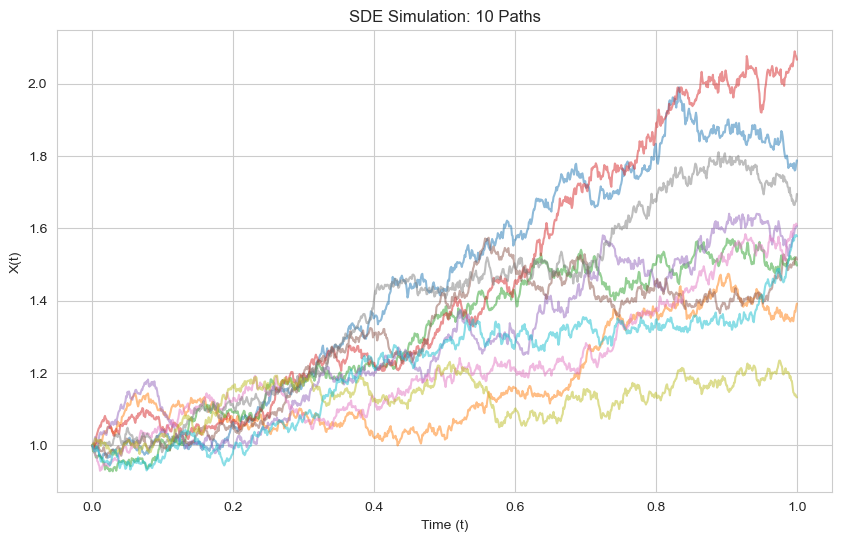

In [4]:
# From src/models/sde_simulator.py, we will implement our code here:

class SDESimulator:
    def __init__(self, drift_func, diffusion_func, paths, points, T=1.0, X0=0.0):
        """
        Initializes the SDE simulator (dX = drift*dt + diffusion*dW).
        """
        self.drift_func = drift_func
        self.diffusion_func = diffusion_func
        self.paths = paths
        self.points = points
        self.T = T
        self.X0 = X0
        self.dt = T / (points - 1)
        self.t_axis = np.linspace(0, T, points)

    def simulate(self):
        """Simulates paths using Euler-Maruyama method."""
        X = np.zeros((self.paths, self.points))
        X[:, 0] = self.X0
        
        # Standard normal random variables for Weiner process
        dW = np.random.normal(0, np.sqrt(self.dt), (self.paths, self.points - 1))
        
        for i in range(self.points - 1):
            X[:, i+1] = X[:, i] + \
                        self.drift_func(X[:, i], self.t_axis[i]) * self.dt + \
                        self.diffusion_func(X[:, i], self.t_axis[i]) * dW[:, i]
        return X

    def plot_paths(self, X):
        """Plots simulation paths."""
        plt.figure(figsize=(10, 6))
        sns.set_style("whitegrid")
        plt.plot(self.t_axis, X.T, alpha=0.5)
        plt.title(f"SDE Simulation: {self.paths} Paths")
        plt.xlabel("Time (t)")
        plt.ylabel("X(t)")
        plt.show()

# --- Test Case ---
if __name__ == '__main__':
    # Example: Geometric Brownian Motion (drift_func=mu*x, diff_func=sigma*x)
    mu, sigma = 0.5, 0.2
    
    # Define SDE functions
    drift = lambda x, t: mu * x
    diffusion = lambda x, t: sigma * x
    
    # Run simulation
    sim = SDESimulator(drift, diffusion, paths=10, points=1000, T=1.0, X0=1.0)
    X = sim.simulate()
    
    # Visualize
    sim.plot_paths(X)


### Stochastic Trajectories and Brownian Motion

The jagged, non-linear paths observed in the simulation are the realized trajectories of a stochastic process known as **Brownian motion** (or a Wiener process). Originating from thermodynamics, this motion describes the random walk of particles suspended in a medium. In the context of optimization, this randomness represents the "noise" inherent in mini-batch sampling.

Because SDEs are driven by these non-differentiable stochastic terms, they require specialized numerical schemes. We utilize the **Euler-Maruyama** method to iteratively approximate the solution path, ensuring that for a specific noise realization, we can track the exact evolution of the parameters $\theta$.



### Comparative Framework: Deterministic vs. Stochastic Dynamics

To understand the impact of noise on convergence and generalization, we compare the standard deterministic gradient update with our SDE-based stochastic model.

#### 1. Deterministic Gradient Descent (The Drift Term)
In a noise-free environment, the parameters follow the path of steepest descent. This is effectively the "drift" component of our SDE:
$$\theta_{t+1} = \theta_{t} - \eta \nabla L(\theta_t)$$
Where $\eta$ is the learning rate. This model assumes perfect knowledge of the gradient and moves directly toward the nearest local minimum.

#### 2. SDE-Based SGD (Drift + Diffusion)
Our Langevin-inspired model incorporates the diffusion tensor $B(\theta)$ to simulate the fluctuations of real-world SGD:
$$\theta_{n+1} = \theta_n - \underbrace{\nabla L(\theta_n) \Delta t}_{\text{Drift}} + \underbrace{\sqrt{2\gamma B(\theta_n) \Delta t} \cdot \epsilon}_{\text{Diffusion}}$$
Where $\epsilon \sim \mathcal{N}(0, I)$. Here, the "noise" allows the parameters to explore the landscape, potentially escaping sharp local minima in favor of flatter, more robust regions.



---
**Simulation Phase:** We will now execute both models simultaneously to visualize how the inclusion of the diffusion term alters the trajectory of the parameter vector $\theta$ across the loss landscape.

--- Results ---
True Params:   theta=4.0, mu=0.1, sigma=0.08
Fitted Params: theta=3.737, mu=0.082, sigma=0.083
MSE (Data vs Analytical Mean): 0.000414


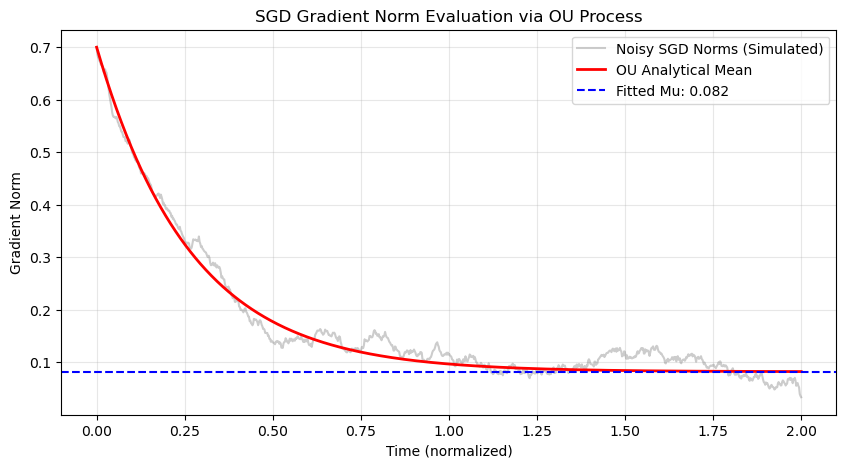

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error

class OUProcess:
    """
    Ornstein-Uhlenbeck Process Simulator for SGD trajectory modeling.
    SDE: dX_t = theta * (mu - X_t) * dt + sigma * dW_t
    """
    def __init__(self, theta=2.0, mu=0.0, sigma=0.5, paths=1, points=1000, T=1.0, X0=None):
        self.theta = theta
        self.mu = mu
        self.sigma = sigma
        self.paths = paths
        self.points = points
        self.T = T
        self.X0 = X0 if X0 is not None else mu
        self.dt = T / (points - 1)
        self.t_axis = np.linspace(0, T, points)

    def simulate(self):
        """Vectorized simulation using Euler-Maruyama."""
        X = np.zeros((self.paths, self.points))
        X[:, 0] = self.X0
        # Pre-generate noise for efficiency
        dW = np.random.normal(0, np.sqrt(self.dt), (self.paths, self.points - 1))
        
        for i in range(self.points - 1):
            # Ito discretization: X_{t+1} = X_t + theta*(mu - X_t)*dt + sigma*dW_t
            X[:, i+1] = X[:, i] + self.theta * (self.mu - X[:, i]) * self.dt + self.sigma * dW[:, i]
        return X

    def fit_to_trajectory(self, trajectory, t=None):
        """
        Fits OU parameters using Maximum Likelihood Estimation (MLE).
        MLE is more robust for stochastic data than direct MSE minimization.
        """
        if t is None: t = np.linspace(0, self.T, len(trajectory))
        dt_arr = np.diff(t)
        dX = np.diff(trajectory)
        X_prev = trajectory[:-1]

        def neg_log_likelihood(params):
            theta, mu, sigma = params
            # Numerical stability: prevent non-positive parameters
            if sigma <= 1e-6 or theta <= 1e-6: return 1e10
            
            # Theoretical change in X and variance for a Gaussian transition
            expected_dX = theta * (mu - X_prev) * dt_arr
            variance = (sigma**2) * dt_arr
            
            # Log-likelihood for a normal distribution transition
            # Sum of log(PDF of normal distribution)
            nll = 0.5 * np.sum(np.log(2 * np.pi * variance) + (dX - expected_dX)**2 / variance)
            return nll

        # Smart initial guess: [unit theta, data mean, scaled volatility]
        init_guess = [1.0, np.mean(trajectory), np.std(dX) / np.sqrt(np.mean(dt_arr))]
        res = minimize(neg_log_likelihood, init_guess, 
                       bounds=[(1e-3, 50), (None, None), (1e-3, 20)])
        
        self.theta, self.mu, self.sigma = res.x
        return res.x

def evaluate_sgd_vs_ou(sgd_norms, t=None):
    """
    Evaluates fit by comparing SGD data against the OU analytical mean.
    Analytical Mean: E[X_t] = X_0 * e^(-theta*t) + mu * (1 - e^(-theta*t))
    """
    if t is None: t = np.linspace(0, 1, len(sgd_norms))
    
    # Fit the model to the specific data provided
    model = OUProcess(X0=sgd_norms[0], T=t[-1], points=len(t))
    theta, mu, sigma = model.fit_to_trajectory(sgd_norms, t)
    
    # The expected deterministic path (the "backbone" of the process)
    expected_path = sgd_norms[0] * np.exp(-theta * t) + mu * (1 - np.exp(-theta * t))
    
    mse = mean_squared_error(sgd_norms, expected_path)
    return [theta, mu, sigma], mse, expected_path

if __name__ == '__main__':
    # 1. Create Synthetic "SGD Gradient Norm" data 
    # (Starting high and decaying toward a noisy equilibrium)
    true_params = {'theta': 4.0, 'mu': 0.1, 'sigma': 0.08}
    t_synth = np.linspace(0, 2, 1000)
    simulator = OUProcess(**true_params, X0=0.7, T=2, points=1000)
    sgd_simulated_data = simulator.simulate()[0]

    # 2. Evaluate and Fit
    fitted_params, mse, mean_path = evaluate_sgd_vs_ou(sgd_simulated_data, t_synth)
    
    print("--- Results ---")
    print(f"True Params:   theta={true_params['theta']}, mu={true_params['mu']}, sigma={true_params['sigma']}")
    print(f"Fitted Params: theta={fitted_params[0]:.3f}, mu={fitted_params[1]:.3f}, sigma={fitted_params[2]:.3f}")
    print(f"MSE (Data vs Analytical Mean): {mse:.6f}")

    # 3. Plotting
    plt.figure(figsize=(10, 5))
    plt.plot(t_synth, sgd_simulated_data, label='Noisy SGD Norms (Simulated)', color='green')
    plt.plot(t_synth, mean_path, label='OU Analytical Mean', color='red', lw=2)
    plt.axhline(fitted_params[1], color='blue', ls='--', label=f'Fitted Mu: {fitted_params[1]:.3f}')
    plt.title('SGD Gradient Norm Evaluation via OU Process')
    plt.xlabel('Time (normalized)')
    plt.ylabel('Gradient Norm')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
